In [ ]:
!pip install visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 48.0 MB/s eta 0:00:00


In [ ]:
!pip install kaggle


In [ ]:
#Upload kaggle.json
from google.colab import files
uploaded = files.upload()

import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

#Download dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

#Extract zip
import zipfile
with zipfile.ZipFile("chest-xray-pneumonia.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/")


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [02:14<00:00, 18.4MB/s]



In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [ ]:
#mengambil folder normal dan pneumonia dari folder train
train_dir = "/content/chest_xray/train"

rows = []
for label in ["NORMAL", "PNEUMONIA"]:
    folder = os.path.join(train_dir, label)
    for fname in os.listdir(folder):
        if fname.lower().endswith(('.png','.jpg','.jpeg')):
            rows.append({"filepath": os.path.join(folder, fname), "label": label})

df = pd.DataFrame(rows)

In [ ]:
#mengambil 2000 citra rontgen thorax dengan rincian 1000 normal dan 1000 pneumonia
df_subset = (
    df.groupby("label", group_keys=False)
      .apply(lambda x: x.sample(n=1000, random_state=42))
      .reset_index(drop=True)
)
print("Subset distribution:\n", df_subset['label'].value_counts())


Subset distribution:
 label
NORMAL       1000
PNEUMONIA    1000
Name: count, dtype: int64


/tmp/ipykernel_7364/2127226444.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=1000, random_state=42))


In [ ]:
train_df, temp_df = train_test_split(
    df_subset,
    test_size=0.30,  # 30% sisa untuk val+test
    stratify=df_subset['label'],
    random_state=42,
    shuffle=True
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,  # 50% dari 30% = 15%. maka 15% untuk uji dan 15% untuk validasi
    stratify=temp_df['label'],
    random_state=42,
    shuffle=True
)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))
print("Train label distribution:\n", train_df['label'].value_counts())
print("Val label distribution:\n", val_df['label'].value_counts())
print("Test label distribution:\n", test_df['label'].value_counts())

Train: 1400 Val: 300 Test: 300
Train label distribution:
 label
NORMAL       700
PNEUMONIA    700
Name: count, dtype: int64
Val label distribution:
 label
PNEUMONIA    150
NORMAL       150
Name: count, dtype: int64
Test label distribution:
 label
PNEUMONIA    150
NORMAL       150
Name: count, dtype: int64


In [ ]:
IMAGE_SIZE = (256, 256)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_datagen = ImageDataGenerator(rescale=1./255)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label',
    target_size=IMAGE_SIZE, class_mode='binary',
    batch_size=BATCH_SIZE, shuffle=True
)
val_gen = val_test_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label',
    target_size=IMAGE_SIZE, class_mode='binary',
    batch_size=BATCH_SIZE, shuffle=False
)
test_gen = val_test_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label',
    target_size=IMAGE_SIZE, class_mode='binary',
    batch_size=BATCH_SIZE, shuffle=False
)


Found 1400 validated image filenames belonging to 2 classes.
Found 300 validated image filenames belonging to 2 classes.
Found 300 validated image filenames belonging to 2 classes.


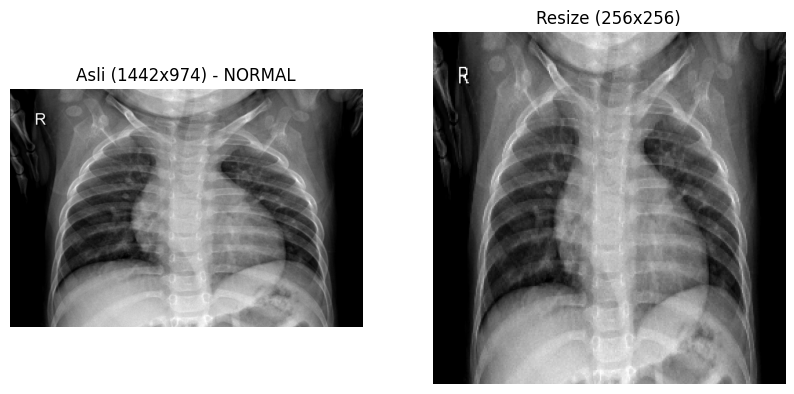

In [ ]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2

# Tentukan folder dataset (ubah sesuai path kamu)
train_dir = "/content/chest_xray/train"

# Pilih kelas secara acak (NORMAL / PNEUMONIA)
label = random.choice(["NORMAL", "PNEUMONIA"])
folder = os.path.join(train_dir, label)

# Pilih 1 file gambar secara acak dari folder tersebut
fname = random.choice(os.listdir(folder))
img_path = os.path.join(folder, fname)

# Baca gambar asli
original_img = mpimg.imread(img_path)

# Resize ke 256x256
resized_img = cv2.resize(original_img, (256, 256))

# Tampilkan gambar
plt.figure(figsize=(10,5))

# Gambar asli
plt.subplot(1,2,1)
plt.imshow(original_img, cmap="gray")
plt.title(f"Asli ({original_img.shape[1]}x{original_img.shape[0]}) - {label}")
plt.axis("off")

# Gambar resize
plt.subplot(1,2,2)
plt.imshow(resized_img, cmap="gray")
plt.title("Resize (256x256)")
plt.axis("off")

plt.show()

In [ ]:
labels = train_df['label'].map({'NORMAL':0, 'PNEUMONIA':1}).values
classes = np.unique(labels)
class_weights = compute_class_weight('balanced', classes=classes, y=labels)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam



model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(256, 256, 3)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,839,105 (56.61 MB)

 Trainable params: 14,839,105 (56.61 MB)

 Non-trainable params: 0 (0.00 B)

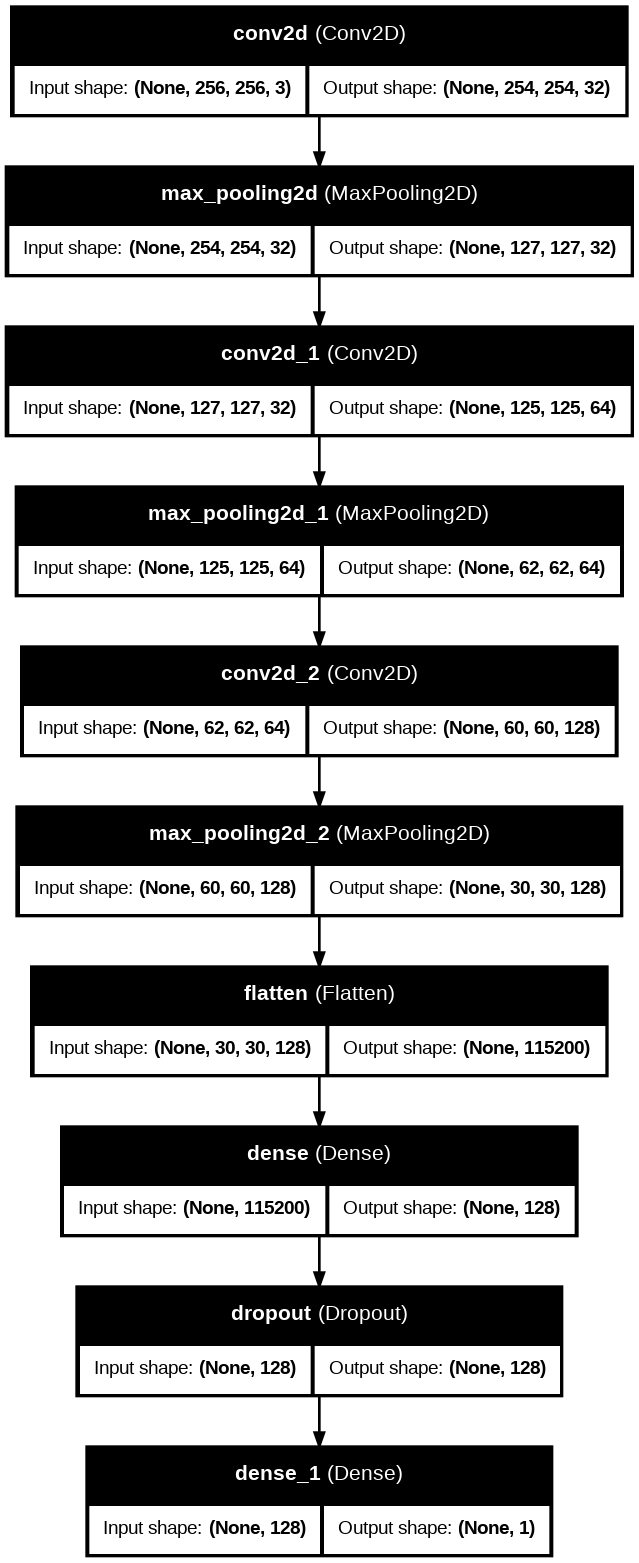

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model, to_file="cnn_model.png", show_shapes=True, show_layer_names=True, dpi=96)

In [ ]:
# @title
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

callbacks = [
  ModelCheckpoint("best_model.keras", save_best_only=True, monitor="val_auc", mode="max"),
  #EarlyStopping(monitor="val_auc", patience=5, restore_best_weights=True),
  #ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3)
]

# Train the model
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.6891 - loss: 0.6664

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_auc available.
  if self._should_save_model(epoch, batch, logs, filepath):


44/44 ━━━━━━━━━━━━━━━━━━━━ 39s 672ms/step - accuracy: 0.8021 - loss: 0.4697 - val_accuracy: 0.9267 - val_loss: 0.2251
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 23s 515ms/step - accuracy: 0.9421 - loss: 0.1592 - val_accuracy: 0.9400 - val_loss: 0.1902
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 469ms/step - accuracy: 0.9643 - loss: 0.0987 - val_accuracy: 0.9467 - val_loss: 0.1832
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 22s 486ms/step - accuracy: 0.9707 - loss: 0.0780 - val_accuracy: 0.9567 - val_loss: 0.2096
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 489ms/step - accuracy: 0.9693 - loss: 0.0898 - val_accuracy: 0.9467 - val_loss: 0.1909
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 472ms/step - accuracy: 0.9800 - loss: 0.0552 - val_accuracy: 0.9600 - val_loss: 0.2336
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 473ms/step - accuracy: 0.9893 - loss: 0.0328 - val_accuracy: 0.9567 - val_loss: 0.2705
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 22s 492ms/step - accuracy: 0.9786 - loss: 0.0465 - val_accuracy: 0.960

In [ ]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(test_gen)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")

# Prediction & Confusion Matrix
y_true = test_gen.classes
y_pred_probs = model.predict(test_gen).ravel()
y_pred = (y_pred_probs > 0.5).astype(int)

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 406ms/step - accuracy: 0.9400 - loss: 0.2657

✅ Test Accuracy: 0.9400
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 317ms/step



Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.95      0.93      0.94       150
   PNEUMONIA       0.93      0.95      0.94       150

    accuracy                           0.94       300
   macro avg       0.94      0.94      0.94       300
weighted avg       0.94      0.94      0.94       300



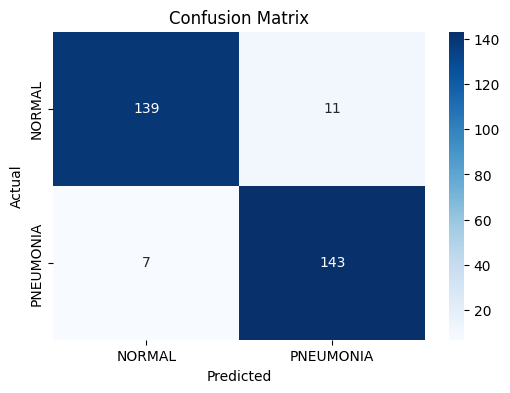

In [ ]:
import seaborn as sns

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"]))

# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NORMAL", "PNEUMONIA"],
            yticklabels=["NORMAL", "PNEUMONIA"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

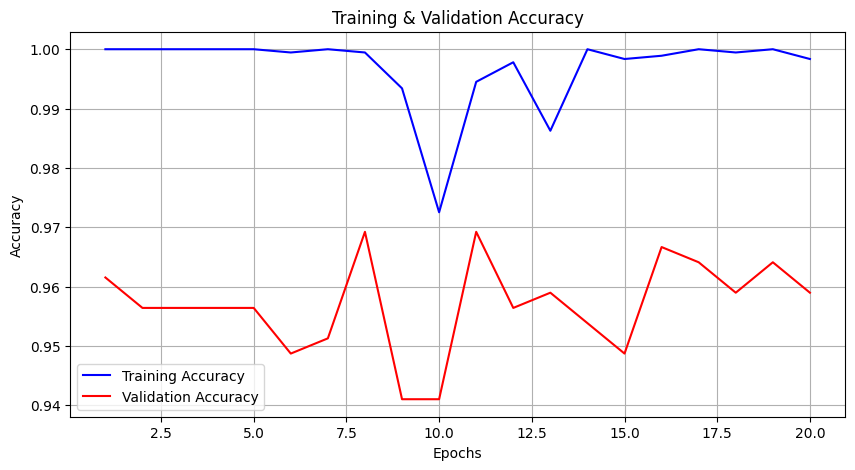

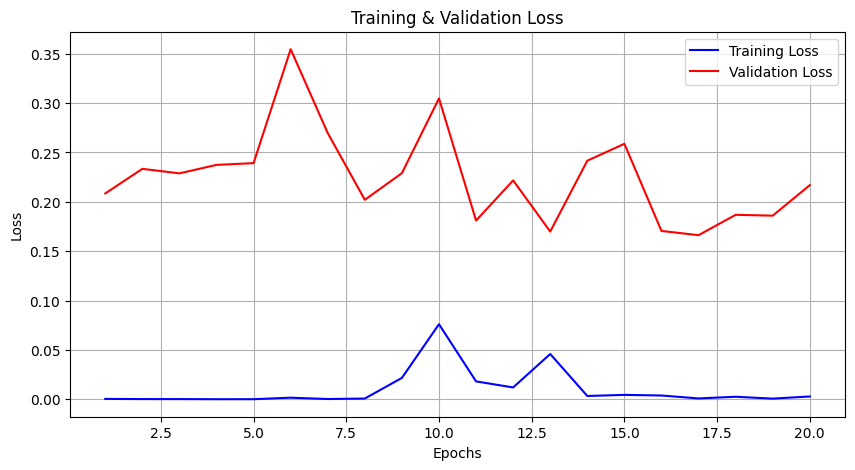

In [ ]:
import matplotlib.pyplot as plt

# Ambil history dari training
history_dict = history.history

acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

# Plot Akurasi
plt.figure(figsize=(10,5))
plt.plot(epochs, acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(10,5))
plt.plot(epochs, loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()
